In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [10]:
df.shape

(74, 20)

In [12]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [15]:
match_wins = df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 1.0, 'Match Wins By Teams')

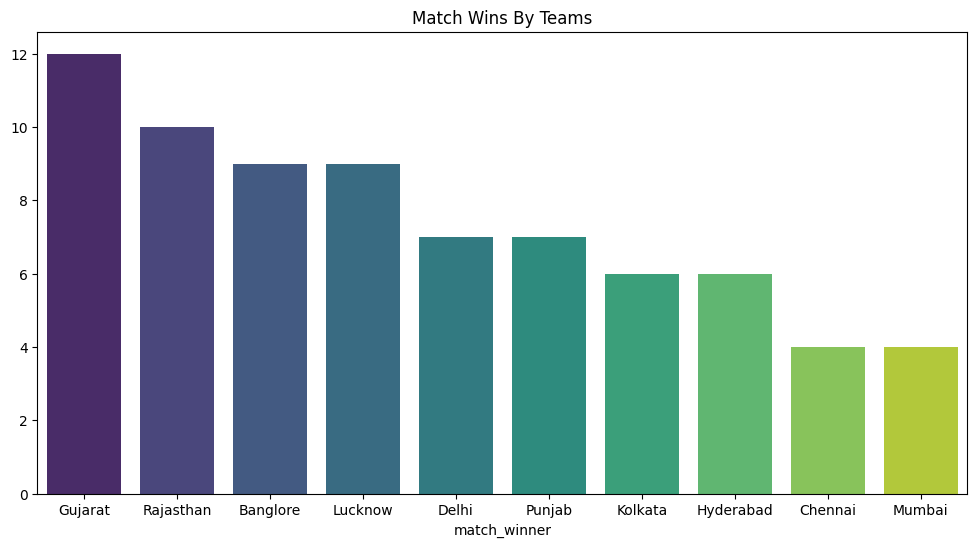

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(x = match_wins.index,y = match_wins.values,palette='viridis')
plt.title("Match Wins By Teams")

Text(0.5, 1.0, 'Toss Decision')

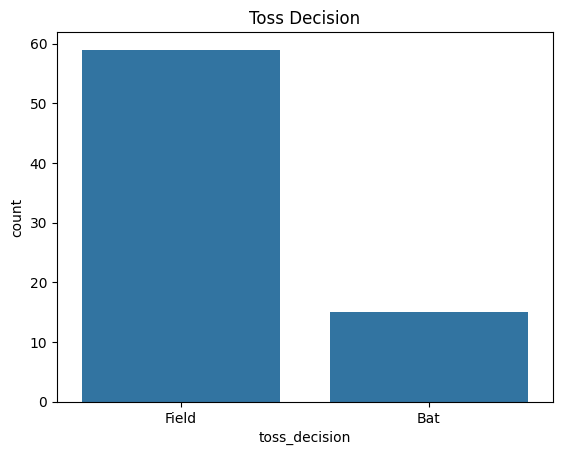

In [32]:
sns.countplot(x = df['toss_decision'])
plt.title("Toss Decision")

In [37]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count * 100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

Text(0.5, 1.0, 'Won By')

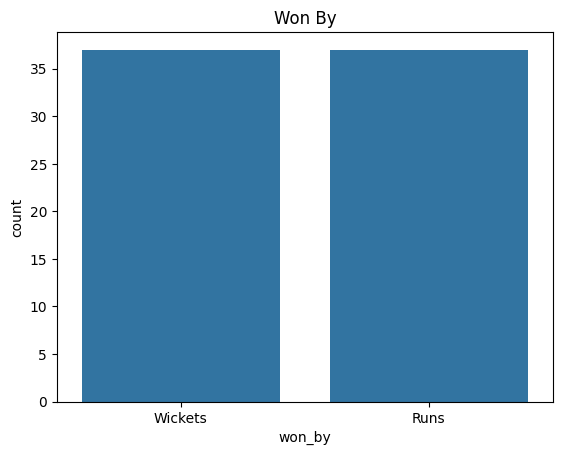

In [39]:
sns.countplot(x = df['won_by'])
plt.title('Won By')

In [48]:
count = df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

Text(0.5, 1.0, 'Top-10 Player Of The Match Award')

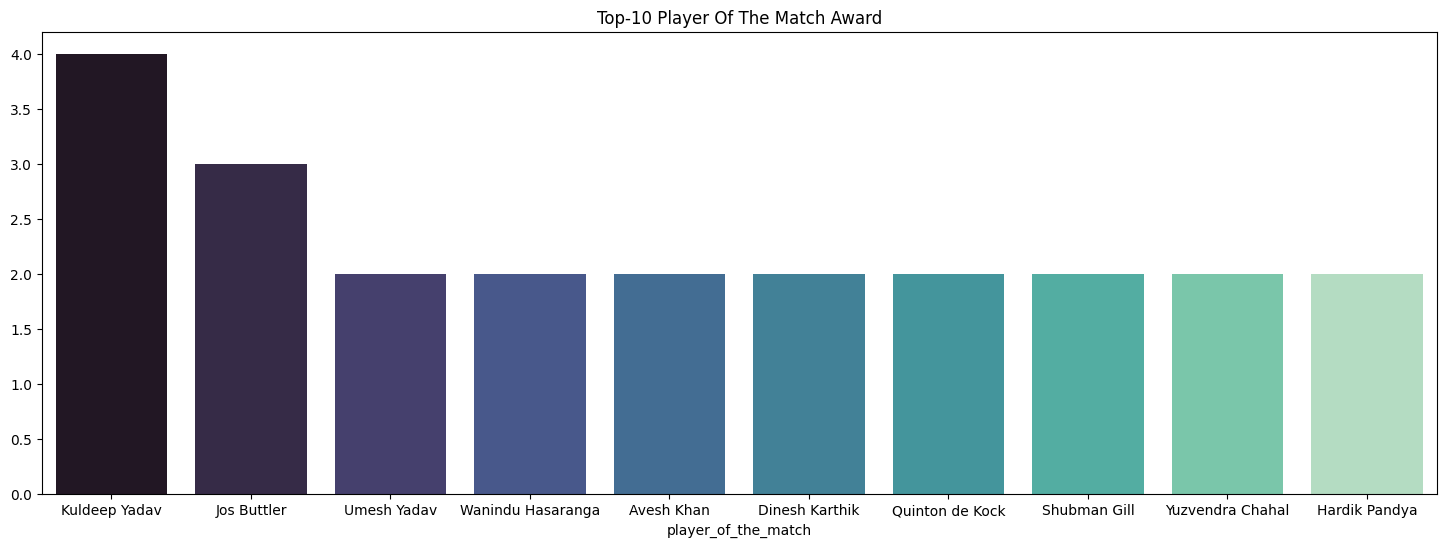

In [58]:
plt.figure(figsize=(18,6))
sns.barplot(x = count.index, y = count.values,palette='mako')
plt.title('Top-10 Player Of The Match Award')

<Axes: xlabel='top_scorer'>

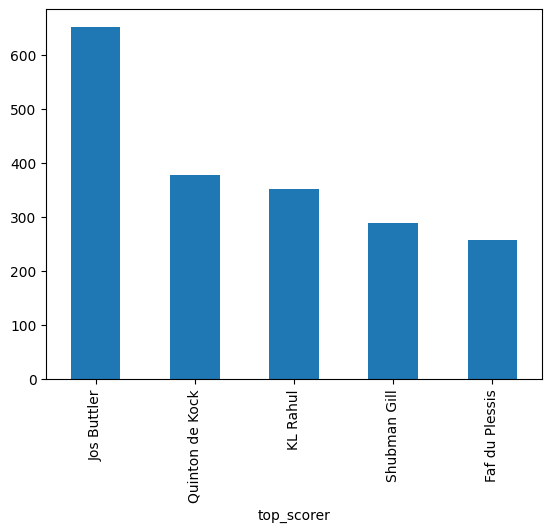

In [81]:
count = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(5)
count
count.plot(kind='bar')

In [93]:
df[['wickets','runs']] = df['best_bowling_figure'].str.split('--',expand=True).astype(int)

df.sort_values(by=['wickets','runs'],ascending=[False,True])[['best_bowling','wickets','runs']].head(5)

,best_bowling,wickets,runs
55,Jasprit Bumrah,5,10
53,Wanindu Hasaranga,5,18
39,Umran Malik,5,25
29,Yuzvendra Chahal,5,40
34,Andre Russell,4,5


<Axes: ylabel='best_bowling'>

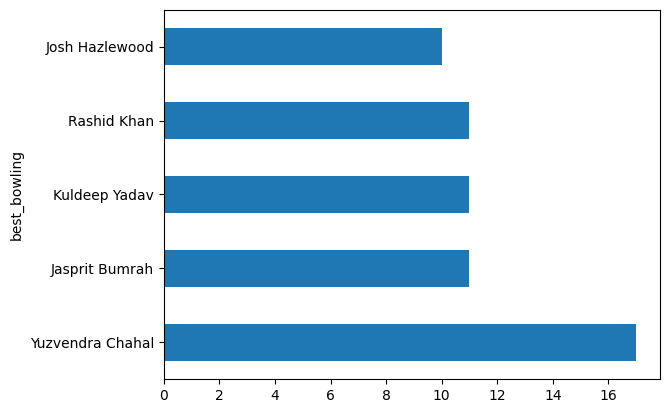

In [99]:
df[['wickets','runs']] = df['best_bowling_figure'].str.split('--',expand=True).astype(int)

df.sort_values(by=['wickets','runs'],ascending=[False,True])[['best_bowling','wickets','runs']].head(5)
top_wickets = df.groupby('best_bowling')['wickets'].sum().sort_values(ascending=False).head(5)
top_wickets.plot(kind='barh')


In [108]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

Text(0.5, 1.0, 'Matches Per Venue')

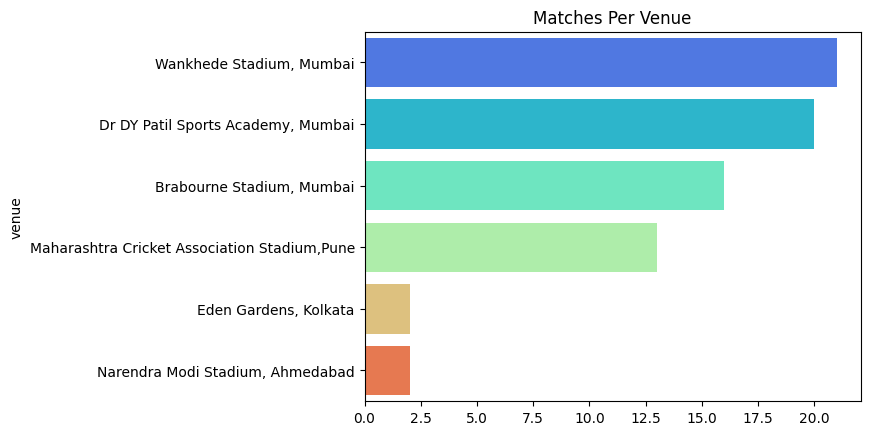

In [112]:
sns.barplot(x = venue_count.values,y = venue_count.index,palette='rainbow')
plt.title('Matches Per Venue')

In [120]:
diff = df[['margin','match_winner']].max()
diff

margin                 91
match_winner    Rajasthan
dtype: object

In [124]:
high = df[['highscore','top_scorer']].max()
high

highscore                  140
top_scorer    Yashasvi Jaiswal
dtype: object